WORKSHEET 1 | DEEP LEARNING | 24BAD074

In [2]:
import numpy as np
from sklearn.metrics import accuracy_score

class Perceptron:

    def __init__(self, num_inputs, learning_rate=0.1):
        self.weights = np.zeros(num_inputs + 1)
        self.learning_rate = learning_rate

    def linear(self, inputs):
        return np.dot(inputs, self.weights[1:]) + self.weights[0]

    def activation(self, z):
        if z >= 0:
            return 1
        else:
            return 0

    def predict(self, inputs):
        z = self.linear(inputs)
        return self.activation(z)

    def train(self, inputs, target):
        prediction = self.predict(inputs)
        error = target - prediction

        self.weights[1:] += self.learning_rate * error * inputs
        self.weights[0] += self.learning_rate * error

    def fit(self, X, y, epochs=100):
        for epoch in range(epochs):
            for inputs, target in zip(X, y):
                self.train(inputs, target)

# New Section

TASK 1



AND GATE


In [7]:
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y_and = np.array([0, 0, 0, 1])
perceptron_and = Perceptron(num_inputs=2)

perceptron_and.fit(
    X,
    y_and,
    epochs=100
)
print("AND Gate Predictions")

for sample in X:
    print(sample, "->", perceptron_and.predict(sample))

and_predictions = [
    perceptron_and.predict(sample)
    for sample in X
]

and_accuracy = accuracy_score(y_and, and_predictions)

print("AND Accuracy:", and_accuracy * 100, "%")

AND Gate Predictions
[0 0] -> 0
[0 1] -> 0
[1 0] -> 0
[1 1] -> 1
AND Accuracy: 100.0 %


OR GATE


In [8]:
y_or = np.array([0, 1, 1, 1])


perceptron_or = Perceptron(num_inputs=2)

perceptron_or.fit(
    X,
    y_or,
    epochs=100
)
print("\nOR Gate Predictions")

for sample in X:
    print(sample, "->", perceptron_or.predict(sample))

or_predictions = [
    perceptron_or.predict(sample)
    for sample in X
]

or_accuracy = accuracy_score(y_or, or_predictions)

print("OR Accuracy:", or_accuracy * 100, "%")


OR Gate Predictions
[0 0] -> 0
[0 1] -> 1
[1 0] -> 1
[1 1] -> 1
OR Accuracy: 100.0 %


TASK 2


Dataset Shape: (569, 30)
Number of Classes: 2

Model Accuracy: 95.61 %

First 10 Predictions
Actual	Predicted
1 	 1
0 	 0
0 	 0
1 	 1
1 	 1
0 	 0
0 	 0
0 	 0
1 	 0
1 	 1


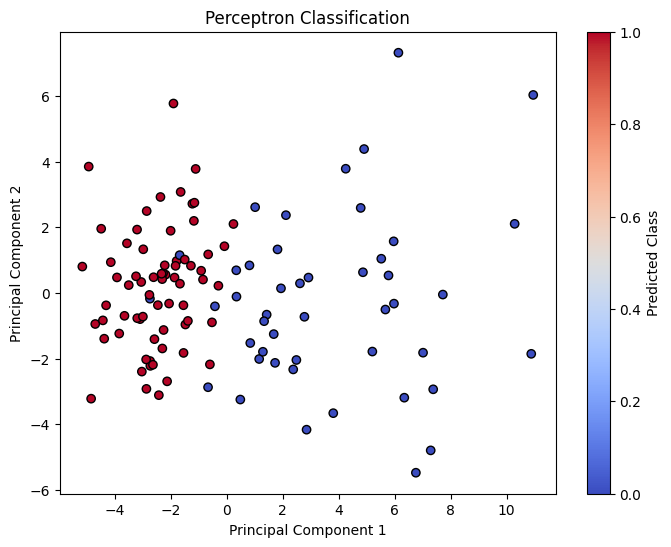

In [9]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.decomposition import PCA


# Single Layer Perceptron Class
class Perceptron:

    def __init__(self, num_inputs, learning_rate=0.1):
        self.weights = np.zeros(num_inputs + 1)
        self.learning_rate = learning_rate

    def linear(self, inputs):
        return np.dot(inputs, self.weights[1:]) + self.weights[0]

    def activation(self, z):
        if z >= 0:
            return 1
        else:
            return 0

    def predict(self, inputs):
        z = self.linear(inputs)
        return self.activation(z)

    def train(self, inputs, target):
        prediction = self.predict(inputs)
        error = target - prediction

        self.weights[1:] += self.learning_rate * error * inputs
        self.weights[0] += self.learning_rate * error

    def fit(self, X, y, epochs=100):
        for epoch in range(epochs):
            for inputs, target in zip(X, y):
                self.train(inputs, target)


# Load Dataset
data = load_breast_cancer()

X = data.data
y = data.target

print("Dataset Shape:", X.shape)
print("Number of Classes:", len(np.unique(y)))

# Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Feature Scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train Perceptron
perceptron = Perceptron(
    num_inputs=X_train.shape[1],
    learning_rate=0.1
)

perceptron.fit(
    X_train,
    y_train,
    epochs=100
)

# Prediction
predictions = []

for sample in X_test:
    predictions.append(perceptron.predict(sample))

# Accuracy
accuracy = accuracy_score(y_test, predictions)

print("\nModel Accuracy:", round(accuracy * 100, 2), "%")

# Display Sample Predictions
print("\nFirst 10 Predictions")
print("Actual\tPredicted")

for actual, predicted in zip(y_test[:10], predictions[:10]):
    print(actual, "\t", predicted)

# Visualization using PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_test)

plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=predictions,
    cmap="coolwarm",
    edgecolors="k"
)

plt.title("Perceptron Classification")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(label="Predicted Class")
plt.show()